# Ximenez Extract Topics

## Set Up

Import tools to convert data from tree to table

In [1]:
from lxml import etree # XML parser
import pandas as pd # Tabular data manipulation
import seaborn as sns # Plotting
import matplotlib.pyplot as plt # Plotting
sns.set_theme(style="darkgrid") # Set seaborn theme

Open the source data into a parse tree.

In [2]:
ns = {'tei':"http://www.tei-c.org/ns/1.0"}
xml_src = "xom-all-flat-mod-pnums.xml"
xml_str = open(xml_src, 'rb').read()
tree = etree.parse(xml_src)
root = tree.getroot()

# Extract Content

## Paragraphs

Extract all paragraphs using XPath.

In [3]:
paras = root.xpath("//tei:div[@xml:lang='quc']//tei:p", namespaces=ns)

Interate over each paragraph element and consoliate text context.

In [4]:
para_list = []
for i, para in enumerate(paras):

    para2 = []
    for el in para.iter():
        para2.append(el.text.strip()) if el.text else None
        para2.append(el.tail.strip()) if el.tail else None
        
    para3 = " ".join(para2)
    para3 = para3.replace(" –  ", "")
    para_list.append(para3)
            

Put into a data frame.

In [5]:
PARA = pd.DataFrame(para_list, columns=['para_str'])
PARA.index.name = 'para_id'

In [13]:
PARA

,para_str
para_id,
0,cap. 1.del serde Díos ARE V XE OHER Ꜩih ...
1,V aral xchicaꜩibah vi xchica 1. tiquiba vi o...
2,"ARE V ꜨIHOXIC VAE Cacaꜩinin oc, caca chamam..."
3,V ae cute nabe ꜩih nabe vchan. mahabi oꜫ hun...
4,T a xpe cut vꜩih varal xul cuq ri tepeu gucu...
...,...
150,ucabahau hun L olmet ahau vnimha
151,roxahau hun N im chocoh ahau unimha.
152,cut vcah ahau hun H acaviꜩ vnim ha chicahibc...


## Extract RS elements (Temas)

In [6]:
rses = root.xpath("//tei:div[@xml:lang='quc']//tei:rs", namespaces=ns)

In [7]:
TEMA_SEQ = pd.DataFrame([rs.get("ana").strip().lower() for rs in rses], columns=['ana_id'])
TEMA_SEQ.index.name = 'seq_id'

In [8]:
TEMA_SEQ

,ana_id
seq_id,
0,dios
1,tinamit_k'iche'
2,tz'aqol
3,b'itol
4,alom
...,...
3189,nim_ch'okoj
3190,tinamit_k'iche'
3191,popol_wuj


In [9]:
TEMA = TEMA_SEQ.ana_id.value_counts().to_frame('n')

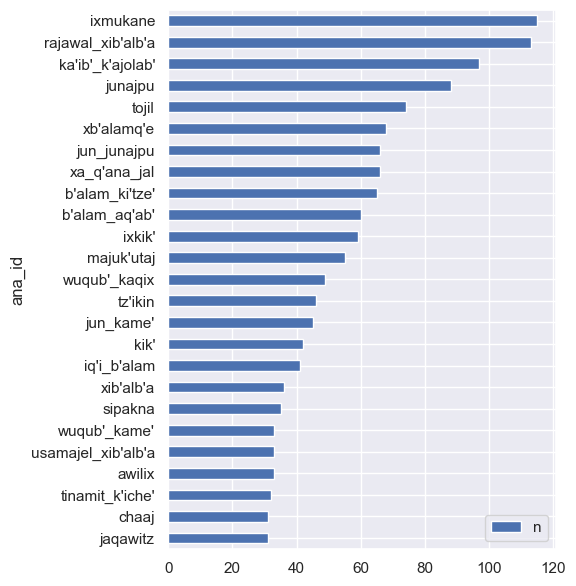

In [10]:
TEMA.head(25).sort_values('n', ascending=True).plot.barh(figsize=(5,7), rot=0);

# Visualize Topics over Narrative Time

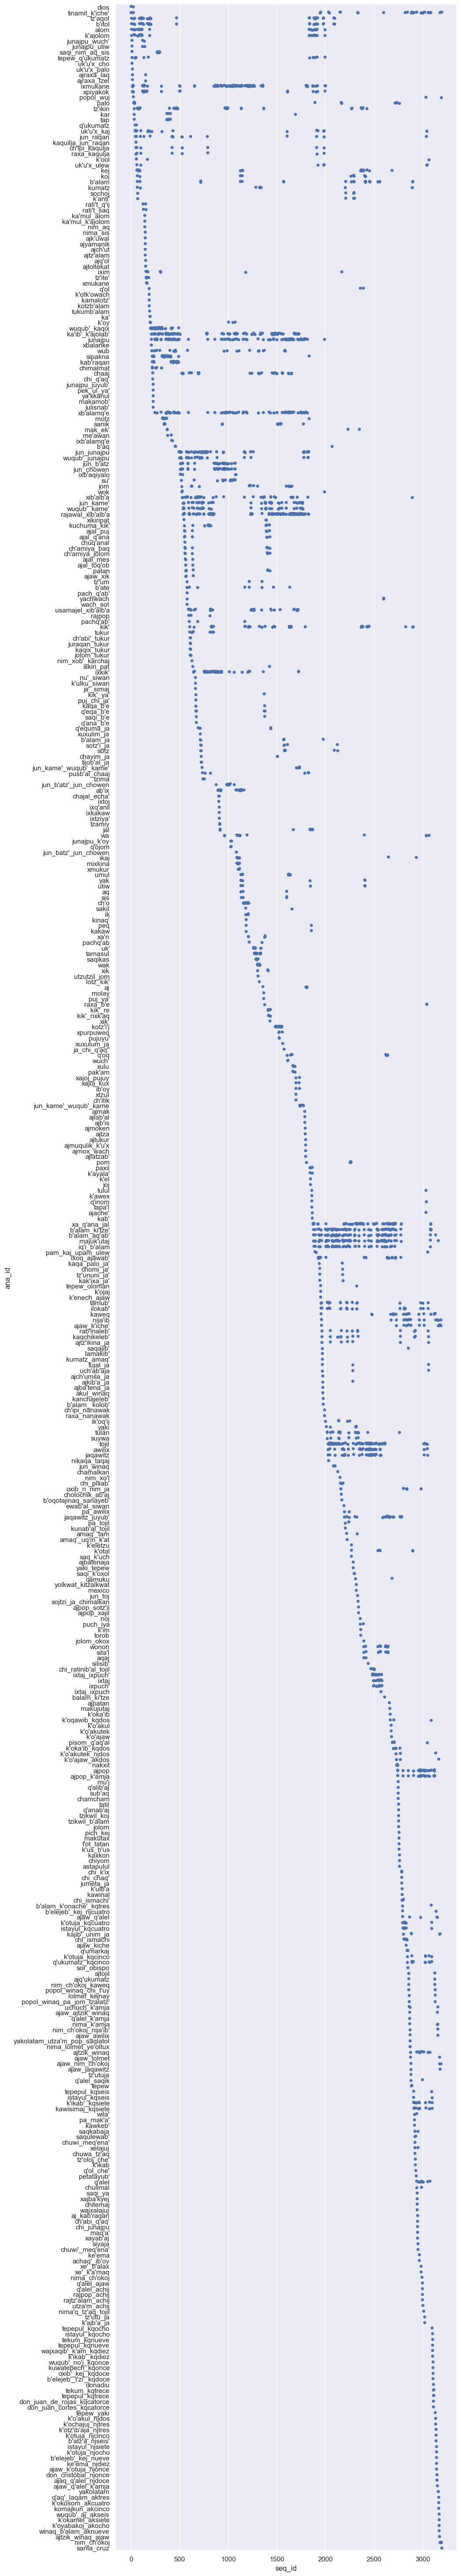

In [11]:
fig, ax = plt.subplots(figsize=(10, 75))
sns.stripplot(x=TEMA_SEQ.index, y=TEMA_SEQ.ana_id, ax=ax);

# Save

In [12]:
TEMA.to_csv("recinos-TEMA.csv", sep="|", index=True)
TEMA_SEQ.to_csv("recinos-TEMA_SEQ.csv", sep="|", index=True)